In [1]:
import pandas as pd

# load dataset
data = pd.read_csv("data/continuous dataset.csv")

# show first rows
print(data.head())

              datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
0  2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
1  2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2  2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   
3  2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273  22.110481   
4  2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281  21.186089   

     T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_dav  \
0  23.482446  0.017272  0.001855  10.328949  22.662134  0.016562  0.096100   
1  23.399255  0.017265  0.001327  10.681517  22.578943  0.016509  0.087646   
2  23.343530  0.017211  0.001428  10.874924  22.531030  0.016479  0.078735   
3  23.238794  0.017128  0.002599  10.518620  22.512231  0.016487  0.068390   
4  23.075403  0.017059  0.001729   9.733589  22.481653  0.016456  0.064362   

    W2M_dav  Holiday_ID  holiday  school  
0  5.36

In [2]:
# convert datetime column to datetime format
data['datetime'] = pd.to_datetime(data['datetime'])

# create time features
data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['day_of_week'] = data['datetime'].dt.dayofweek

# check the result
print(data[['datetime','hour','day','month','day_of_week']].head())

             datetime  hour  day  month  day_of_week
0 2015-01-03 01:00:00     1    3      1            5
1 2015-01-03 02:00:00     2    3      1            5
2 2015-01-03 03:00:00     3    3      1            5
3 2015-01-03 04:00:00     4    3      1            5
4 2015-01-03 05:00:00     5    3      1            5


In [3]:
# target variable (what we want to predict)
y = data['nat_demand']

# input features
X = data[['T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
          'hour','day','month','day_of_week',
          'holiday','school']]

print(X.head())
print(y.head())

     T2M_toc  QV2M_toc   TQL_toc    W2M_toc  hour  day  month  day_of_week  \
0  25.865259  0.018576  0.016174  21.850546     1    3      1            5   
1  25.899255  0.018653  0.016418  22.166944     2    3      1            5   
2  25.937280  0.018768  0.015480  22.454911     3    3      1            5   
3  25.957544  0.018890  0.016273  22.110481     4    3      1            5   
4  25.973840  0.018981  0.017281  21.186089     5    3      1            5   

   holiday  school  
0        0       0  
1        0       0  
2        0       0  
3        0       0  
4        0       0  
0    970.3450
1    912.1755
2    900.2688
3    889.9538
4    893.6865
Name: nat_demand, dtype: float64


In [23]:
data.isnull().sum()

datetime       0
nat_demand     0
T2M_toc        0
QV2M_toc       0
TQL_toc        0
W2M_toc        0
T2M_san        0
QV2M_san       0
TQL_san        0
W2M_san        0
T2M_dav        0
QV2M_dav       0
TQL_dav        0
W2M_dav        0
Holiday_ID     0
holiday        0
school         0
hour           0
day            0
month          0
day_of_week    0
lag_1          0
lag_2          0
lag_24         0
dtype: int64

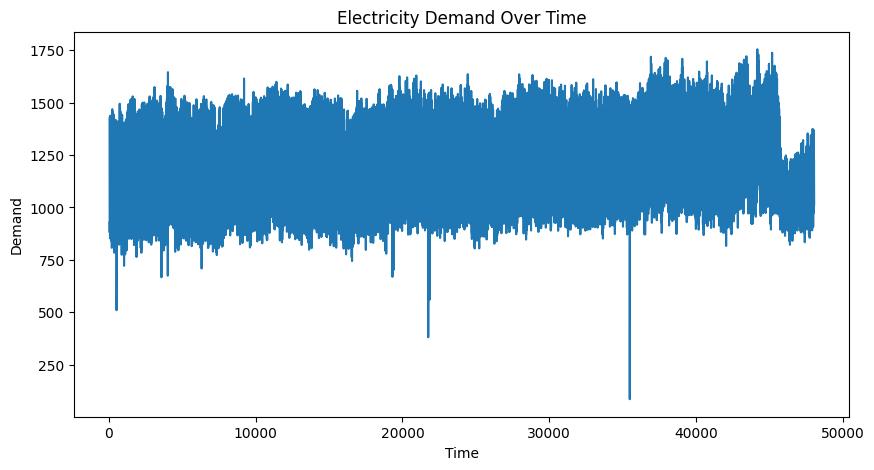

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data['nat_demand'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

In [25]:
print(data.columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour', 'day',
       'month', 'day_of_week', 'lag_1', 'lag_2', 'lag_24'],
      dtype='object')


In [29]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [30]:
data = data.sort_values("datetime").reset_index(drop=True)

In [31]:
data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['day_of_week'] = data['datetime'].dt.dayofweek

In [32]:
data['lag_1'] = data['nat_demand'].shift(1)
data['lag_2'] = data['nat_demand'].shift(2)
data['lag_24'] = data['nat_demand'].shift(24)

In [33]:
data = data.dropna()

In [34]:
y = data["nat_demand"]

X = data[['T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
          'hour','day','month','day_of_week',
          'holiday','school',
          'lag_1','lag_2','lag_24']]

In [35]:
print(data.columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour', 'day',
       'month', 'day_of_week', 'lag_1', 'lag_2', 'lag_24'],
      dtype='object')


In [37]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained with lag features")

Model trained with lag features


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

MAE: 18.626230850204422
RMSE: 26.336831704207977
R2 Score: 0.9799522466329864


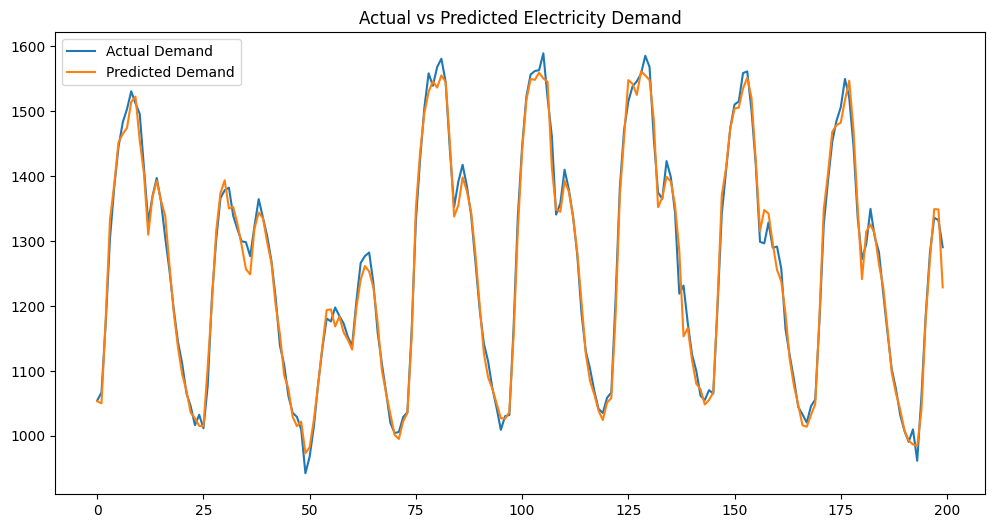

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual Demand")
plt.plot(y_pred[:200], label="Predicted Demand")
plt.legend()
plt.title("Actual vs Predicted Electricity Demand")
plt.show()

lag_1          0.896770
hour           0.064007
lag_24         0.019648
lag_2          0.009915
day_of_week    0.002920
T2M_toc        0.001509
W2M_toc        0.001147
QV2M_toc       0.001022
TQL_toc        0.000944
month          0.000715
day            0.000713
holiday        0.000595
school         0.000094
dtype: float64


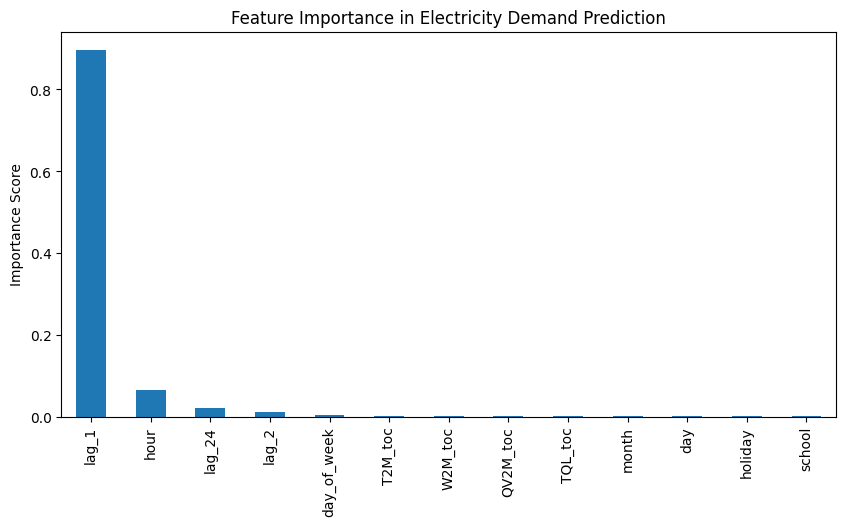

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importance
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

# sort
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

# plot
plt.figure(figsize=(10,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance in Electricity Demand Prediction")
plt.ylabel("Importance Score")
plt.show()

In [43]:
peak_threshold = 1500  # adjust based on dataset

for value in y_pred[:50]:
    if value > peak_threshold:
        print("⚠ Peak demand expected:", value)

⚠ Peak demand expected: 1514.4063659999997
⚠ Peak demand expected: 1522.4617059999998


In [44]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

Grid Optimization ML Model

In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/continuous dataset.csv")

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

In [47]:
# Basic features
df["hour"] = df["datetime"].dt.hour
df["temp"] = df["T2M_toc"]   # already exists
df["demand"] = df["nat_demand"]

# Simulate renewable ratio (important)
df["renewable_ratio"] = (
    (df["TQL_toc"] / 100) * 0.3 +
    (df["W2M_toc"] / df["W2M_toc"].max()) * 0.2
)

df["temp"] = df["temp"] + np.random.normal(0, 1, len(df))
df["demand"] = df["demand"] + np.random.normal(0, 5, len(df))

In [48]:
df["action"] = 0

for i in range(len(df)):

    demand = df.loc[i, "demand"]
    temp = df.loc[i, "temp"]
    renewable = df.loc[i, "renewable_ratio"]

    if demand > 500 and temp > 30 and renewable < 0.3:
        df.loc[i, "action"] = 2   # critical

    elif demand > 400:
        df.loc[i, "action"] = 1   # moderate

    else:
        df.loc[i, "action"] = 0   # normal

In [54]:
from sklearn.utils import resample

df_majority = df[df.action == 1]
df_minority_0 = df[df.action == 0]
df_minority_2 = df[df.action == 2]

# Upsample minority classes
df_minority_0_upsampled = resample(df_minority_0,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_minority_2_upsampled = resample(df_minority_2,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

# Combine
df = pd.concat([df_majority, df_minority_0_upsampled, df_minority_2_upsampled])

In [55]:
df = df.sample(frac=1).reset_index(drop=True)

In [57]:
# add randomness to make it imperfect
noise_idx = np.random.choice(df.index, size=int(0.1*len(df)), replace=False)
df.loc[noise_idx, "action"] = np.random.choice([0,1,2], size=len(noise_idx))

In [58]:
print(df["action"].value_counts())

action
2    40380
1    40374
0    40305
Name: count, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

X = df[["demand", "temp", "renewable_ratio"]]
y = df["action"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
model_opt = RandomForestClassifier(n_estimators=100)
model_opt.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred = model_opt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8621344787708575
[[7052  508  496]
 [ 565 6994  578]
 [ 607  584 6828]]


In [62]:
import joblib
joblib.dump(model_opt, "model/grid_optimizer.pkl")

['model/grid_optimizer.pkl']